# [실습6] 양극재 결정구조 예측 딥러닝 모델 성능 향상을 위한 다양한 기법 (정답)
---

## 실습 목표

- 딥러닝 학습 시 적용할 수 있는 심화 기법들을 이해하고 구현합니다.
- 기법들의 적용 유무에 따른 성능을 비교해봅니다. 각각 토이 데이터셋과 실습 데이터셋에서 검증합니다.

---

## 실습 목차

1. **토이 데이터셋 불러오기 및 전처리 적용** 

2. **학습 테스트 결과 추적** 

3. **조기 종료(Early Stopping)**

4. **그래픽카드 사용하기** 

5. **데이터 증강** 

6. **가중치 규제**

7. **드롭아웃(Dropout)**

8. **실습 데이터 불러오기 및 딥러닝 기법 적용** 

9. **AutoML**
---

## 실습 개요

이번 실습에서는 머신러닝 분류 모델들을 구현하고 실습 데이터에 어떻게 적용될 수 있는지 확인합니다.

---

## 1. 토이 데이터셋 불러오기 및 전처리 적용
---
기존에 다뤘던 전처리를 모두 적용해 학습 & 테스트 데이터를 구분하겠습니다.

In [1]:
## 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from warnings import simplefilter
simplefilter(action='ignore', category=FutureWarning)

### 1.1 토이 데이터셋 불러오기
타이타닉 데이터셋을 불러옵니다.

In [2]:
df = pd.read_csv('./data/titanic_processed.csv') # df: dataframe의 줄임말
df.drop(columns = df.columns[0], axis = 1, inplace= True) # 데이터 순서를 표현하는 첫 열을 제거합니다.
display(df)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,title,gender,grade
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",Miss,0,0
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",Rare_m,1,4
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",Miss,0,0
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",Mr,1,1
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",Mrs,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1040,3,0,"Youseff, Mr. Gerious",male,45.5000,0,0,2628,7.2250,NaN,C,NaN,312.0,NaN,Mr,1,1
1041,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN,Miss,0,0
1042,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN,Mr,1,1
1043,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN,Mr,1,1


해당 승객의 생존 여부를 정답 데이터로 지정하겠습니다. 나머지 데이터를 입력 데이터로 지정합니다.

In [3]:
from sklearn.model_selection import train_test_split

X = df[['pclass', 'age', 'sibsp', 'parch', 'fare', 'gender', 'embarked']]
y = df['survived']

display(X)
display(y)


,pclass,age,sibsp,parch,fare,gender,embarked
0,1,29.0000,0,0,211.3375,0,S
1,1,0.9167,1,2,151.5500,1,S
2,1,2.0000,1,2,151.5500,0,S
3,1,30.0000,1,2,151.5500,1,S
4,1,25.0000,1,2,151.5500,0,S
...,...,...,...,...,...,...,...
1040,3,45.5000,0,0,7.2250,1,C
1041,3,14.5000,1,0,14.4542,0,C
1042,3,26.5000,0,0,7.2250,1,C
1043,3,27.0000,0,0,7.2250,1,C


0       1
1       1
2       0
3       0
4       0
       ..
1040    0
1041    0
1042    0
1043    0
1044    0
Name: survived, Length: 1045, dtype: int64

---
### 1.2 원-핫 인코딩(One-Hot Encoding)
범주형 데이터에 대해 원-핫 인코딩을 적용해보겠습니다.

pclass에 원-핫 인코딩 적용합니다.

In [4]:
dummies = pd.get_dummies(X['pclass']).astype('int')
dummies.columns = ['1class', '2class', '3class']

X.drop('pclass', axis=1, inplace=True)
X = X.join(dummies)

/tmp/ipykernel_53/2712291237.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.drop('pclass', axis=1, inplace=True)


gender에 원-핫 인코딩 적용합니다.

In [5]:
dummies = pd.get_dummies(X['gender']).astype('int')
dummies.columns = ['female', 'male']
X.drop('gender', axis=1, inplace=True)
X = X.join(dummies)

embarked에 원-핫 인코딩을 적용합니다.

In [6]:
dummies = pd.get_dummies(X['embarked']).astype('int')
dummies.columns = ['S', 'C', 'Q']

X.drop('embarked', axis=1, inplace=True)
X = X.join(dummies)

---
### 1.3 정규화 & 표준화
원-핫 인코딩이 완료된 토이 데이터셋에 정규화와 표준화를 진행합니다. 

In [7]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
std_scaler.fit(X)
scaled_X = std_scaler.transform(X)
X = pd.DataFrame(scaled_X, columns=X.columns, index=list(X.index.values))
display(X)

,age,sibsp,parch,fare,1class,2class,3class,female,male,S,C,Q
0,-0.059228,-0.551897,-0.501462,3.135243,1.636941,-0.576982,-0.957826,1.301268,-1.301268,-0.504482,-0.224168,0.581402
1,-2.011855,0.544553,1.880484,2.061972,1.636941,-0.576982,-0.957826,-0.768481,0.768481,-0.504482,-0.224168,0.581402
2,-1.936534,0.544553,1.880484,2.061972,1.636941,-0.576982,-0.957826,1.301268,-1.301268,-0.504482,-0.224168,0.581402
3,0.010302,0.544553,1.880484,2.061972,1.636941,-0.576982,-0.957826,-0.768481,0.768481,-0.504482,-0.224168,0.581402
4,-0.337347,0.544553,1.880484,2.061972,1.636941,-0.576982,-0.957826,1.301268,-1.301268,-0.504482,-0.224168,0.581402
...,...,...,...,...,...,...,...,...,...,...,...,...
1040,1.088014,-0.551897,-0.501462,-0.528869,-0.610895,-0.576982,1.044031,-0.768481,0.768481,1.982232,-0.224168,-1.719981
1041,-1.067411,0.544553,-0.501462,-0.399094,-0.610895,-0.576982,1.044031,1.301268,-1.301268,1.982232,-0.224168,-1.719981
1042,-0.233052,-0.551897,-0.501462,-0.528869,-0.610895,-0.576982,1.044031,-0.768481,0.768481,1.982232,-0.224168,-1.719981
1043,-0.198288,-0.551897,-0.501462,-0.528869,-0.610895,-0.576982,1.044031,-0.768481,0.768481,1.982232,-0.224168,-1.719981


---
### 1.4 학습 & 테스트 데이터 구분

In [8]:
from keras.utils import to_categorical

random_seed = 42
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size = 0.3, random_state = random_seed)
Y_train = to_categorical(Y_train)
Y_test_cat = to_categorical(Y_test)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test_cat.shape)

2023-07-26 09:11:14.121855: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-07-26 09:11:14.576130: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-07-26 09:11:16.420374: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2023-07-26 09:11:16.420563: W tensorflow/

(731, 12)
(314, 12)
(731, 2)
(314, 2)


---
## 2. 학습 테스트 결과 추적
MLP 모델을 구현하고, 데이터를 학습하는 과정을 추적합니다.

---
### 2.1 MLP 모델 구성
우선 MLP 모델을 만듭니다.

In [9]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input

tf.random.set_seed(random_seed)
np.random.seed(random_seed)

MLP_model = tf.keras.Sequential([
    Input(shape=X_train.shape[1]),
    tf.keras.layers.Dense(64, activation = 'relu'),
    tf.keras.layers.Dense(64, activation = 'relu'),
    tf.keras.layers.Dense(32, activation = 'relu'),
    tf.keras.layers.Dense(2, activation='softmax')
])

2023-07-26 09:11:18.973660: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-07-26 09:11:20.048345: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1613] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7924 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe MIG 1g.10gb, pci bus id: 0000:ca:00.0, compute capability: 8.0


---
### 2.2 학습 방법 설정
손실 함수와 최적화함수를 설정합니다.

In [10]:
lr = 0.0001
MLP_model.compile(loss = 'categorical_crossentropy',
              optimizer = tf.keras.optimizers.Adam(learning_rate = lr),
              metrics=['accuracy']
)

---
### 2.3 모델 학습
테스트 데이터를 검증 데이터로 사용하겠습니다.

In [11]:
epoch = 300
history = MLP_model.fit(X_train, Y_train, epochs = epoch, 
                        batch_size = 16, verbose = 1, validation_data=(X_test, Y_test_cat))
print(history)

Epoch 1/300


2023-07-26 09:11:22.271790: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:630] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2023-07-26 09:11:22.295329: I tensorflow/compiler/xla/service/service.cc:173] XLA service 0x55a381f21390 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2023-07-26 09:11:22.295374: I tensorflow/compiler/xla/service/service.cc:181]   StreamExecutor device (0): NVIDIA A100 80GB PCIe MIG 1g.10gb, Compute Capability 8.0
2023-07-26 09:11:22.339434: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2023-07-26 09:11:22.666346: I tensorflow/compiler/jit/xla_compilation_cache.cc:477] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


46/46 [==============================] - 3s 8ms/step - loss: 0.6423 - accuracy: 0.6566 - val_loss: 0.6465 - val_accuracy: 0.6051
Epoch 2/300
46/46 [==============================] - 0s 3ms/step - loss: 0.5827 - accuracy: 0.7196 - val_loss: 0.6054 - val_accuracy: 0.7070
Epoch 3/300
46/46 [==============================] - 0s 4ms/step - loss: 0.5390 - accuracy: 0.7962 - val_loss: 0.5746 - val_accuracy: 0.7452
Epoch 4/300
46/46 [==============================] - 0s 3ms/step - loss: 0.5068 - accuracy: 0.8140 - val_loss: 0.5541 - val_accuracy: 0.7452
Epoch 5/300
46/46 [==============================] - 0s 3ms/step - loss: 0.4835 - accuracy: 0.8153 - val_loss: 0.5375 - val_accuracy: 0.7452
Epoch 6/300
46/46 [==============================] - 0s 3ms/step - loss: 0.4644 - accuracy: 0.8194 - val_loss: 0.5284 - val_accuracy: 0.7452
Epoch 7/300
46/46 [==============================] - 0s 3ms/step - loss: 0.4501 - accuracy: 0.8194 - val_loss: 0.5199 - val_accuracy: 0.7516
Epoch 8/300
46/46 [======

---
### 2.4 학습 결과 시각화
학습 & 테스트 결과를 시각화합니다. 먼저 손실량(loss)에 대해 시각화합니다.

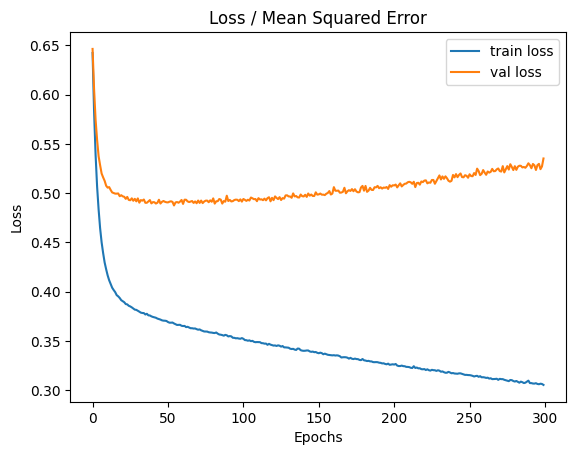

In [12]:
plt.title('Loss / Mean Squared Error')
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend()
plt.show()

정답률에 대해서도 시각화합니다.

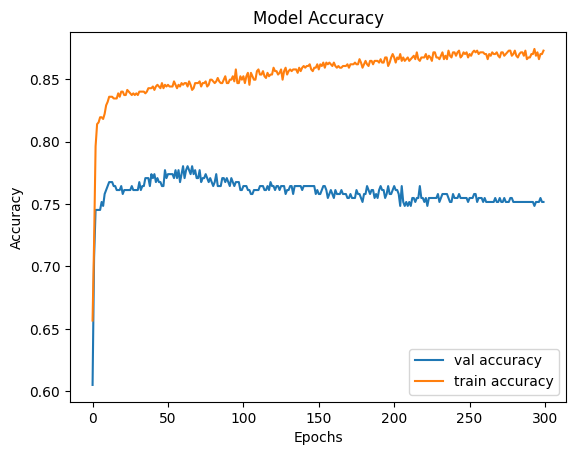

In [13]:
plt.title('Model Accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.plot(history.history['accuracy'], label='train accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.show()

학습이 일정 에폭 이상 진행되면 더이상 검증 성능이 개선되지 않는 것을 확인할 수 있습니다.

---
## 3. 조기 종료(Early Stopping)
학습이 더이상 개선되지 않는다고 판단되면 학습 과정을 조기 종료시킵니다.

---
### 3.1 조기 종료 설정
keras 라이브러리에 내장된 EarlyStopping 콜백 함수를 사용하겠습니다.

검증 손실량이 30 에폭 이상 개선되지 않으면 과정을 조기 종료시키겠습니다.

In [14]:
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor = 'val_loss', min_delta = 0, 
                               patience = 30, mode = 'auto',
                               restore_best_weights=True)

---
### 3.2 모델 학습 및 결과 시각화

In [15]:
MLP_model = tf.keras.Sequential([
    Input(shape=X_train.shape[1]),
    tf.keras.layers.Dense(64, activation = 'relu'),
    tf.keras.layers.Dense(64, activation = 'relu'),
    tf.keras.layers.Dense(32, activation = 'relu'),
    tf.keras.layers.Dense(2, activation='softmax')
])

In [16]:
lr = 0.0001
MLP_model.compile(loss = 'categorical_crossentropy',
              optimizer = tf.keras.optimizers.Adam(learning_rate = lr),
              metrics=['accuracy']
)

In [17]:
history = MLP_model.fit(X_train, Y_train, 
                        epochs = epoch, 
                        batch_size = 16, 
                        verbose = 1, 
                        validation_data=(X_test, Y_test_cat),
                        callbacks = [early_stopping])

Epoch 1/300
46/46 [==============================] - 1s 7ms/step - loss: 0.6697 - accuracy: 0.6142 - val_loss: 0.6580 - val_accuracy: 0.6338
Epoch 2/300
46/46 [==============================] - 0s 3ms/step - loss: 0.6108 - accuracy: 0.6895 - val_loss: 0.6195 - val_accuracy: 0.6624
Epoch 3/300
46/46 [==============================] - 0s 3ms/step - loss: 0.5687 - accuracy: 0.7237 - val_loss: 0.5884 - val_accuracy: 0.7038
Epoch 4/300
46/46 [==============================] - 0s 3ms/step - loss: 0.5347 - accuracy: 0.7661 - val_loss: 0.5652 - val_accuracy: 0.7389
Epoch 5/300
46/46 [==============================] - 0s 3ms/step - loss: 0.5069 - accuracy: 0.7866 - val_loss: 0.5460 - val_accuracy: 0.7548
Epoch 6/300
46/46 [==============================] - 0s 3ms/step - loss: 0.4829 - accuracy: 0.8016 - val_loss: 0.5318 - val_accuracy: 0.7484
Epoch 7/300
46/46 [==============================] - 0s 3ms/step - loss: 0.4629 - accuracy: 0.8057 - val_loss: 0.5213 - val_accuracy: 0.7516
Epoch 8/300
4

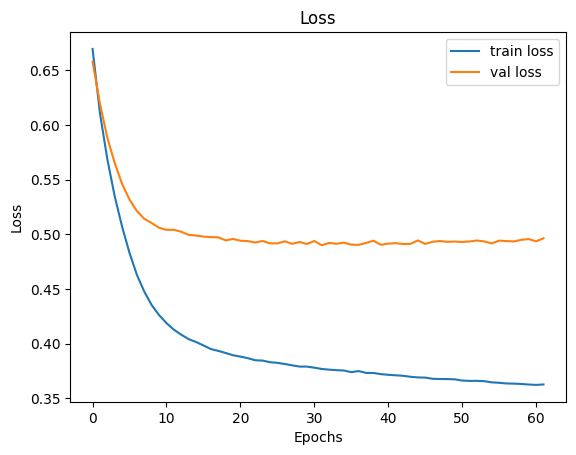

In [18]:
plt.title('Loss')
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend()
plt.show()

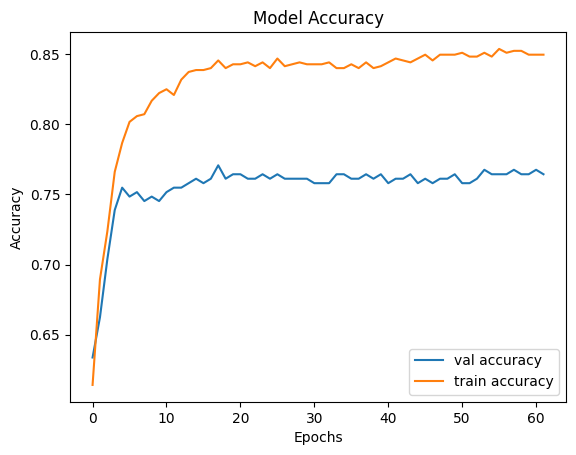

In [19]:
plt.title('Model Accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.plot(history.history['accuracy'], label='train accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.show()

---
## 4. 그래픽카드 사용하기

큰 데이터셋을 학습할 때는 학습 시간이 매우 오래걸립니다.

이때, 적절한 그래픽카드를 사용하면 학습 시간을 크게 단축할 수 있습니다.

---
### 4.1 그래픽카드 정보 확인


In [20]:
from tensorflow.python.client import device_lib

print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 4366151077843663539
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 8308916224
locality {
  bus_id: 2
  numa_node: 1
  links {
  }
}
incarnation: 5470367030240245780
physical_device_desc: "device: 0, name: NVIDIA A100 80GB PCIe MIG 1g.10gb, pci bus id: 0000:ca:00.0, compute capability: 8.0"
xla_global_id: 416903419
]


2023-07-26 09:12:19.020142: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1613] Created device /device:GPU:0 with 7924 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe MIG 1g.10gb, pci bus id: 0000:ca:00.0, compute capability: 8.0


CPU와 그래픽카드(GPU)의 정보를 확인할 수 있습니다.

첫번째 GPU는 GPU:0으로 표기됩니다.

---
### 4.2 그래픽카드를 이용한 학습
정확한 학습 속도 비교를 위해 Early Stopping을 적용하지 않고 학습을 진행해보겠습니다.

각각 CPU와 GPU를 이용해 학습을 진행합니다.

In [21]:
with tf.device("/device:CPU:0"):
    MLP_model = tf.keras.Sequential([
        Input(shape=X_train.shape[1]),
        tf.keras.layers.Dense(64, activation = 'relu'),
        tf.keras.layers.Dense(128, activation = 'relu'),
        tf.keras.layers.Dense(512, activation = 'relu'),
        tf.keras.layers.Dense(2048, activation = 'relu'),
        tf.keras.layers.Dense(1024, activation = 'relu'),
        tf.keras.layers.Dense(512, activation = 'relu'),
        tf.keras.layers.Dense(128, activation = 'relu'),
        tf.keras.layers.Dense(2, activation='softmax')
    ])
    lr = 0.0001
    MLP_model.compile(loss = 'categorical_crossentropy',
                  optimizer = tf.keras.optimizers.Adam(learning_rate = lr),
                  metrics=['accuracy']
    )

먼저 CPU를 이용해 300 에폭을 학습시키겠습니다.

In [22]:
import time

with tf.device("/device:CPU:0"):
    start_time = time.time()
    history = MLP_model.fit(X_train, Y_train, 
                            epochs = 300, 
                            batch_size = 16, 
                            verbose = 0, 
                            validation_data=(X_test, Y_test_cat))
    end_time = time.time()

2023-07-26 09:12:20.288351: I tensorflow/compiler/xla/service/service.cc:173] XLA service 0x55a3831f96c0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2023-07-26 09:12:20.288399: I tensorflow/compiler/xla/service/service.cc:181]   StreamExecutor device (0): Host, Default Version


In [23]:
print("{} 에폭을 학습하는데 총 {:.3f} 초가 걸렸습니다.".format(epoch, end_time-start_time))

300 에폭을 학습하는데 총 166.748 초가 걸렸습니다.


다음 GPU를 이용해 300 에폭을 학습시키겠습니다.

In [24]:
with tf.device("/device:GPU:0"):
    MLP_model = tf.keras.Sequential([
        Input(shape=X_train.shape[1]),
        tf.keras.layers.Dense(64, activation = 'relu'),
        tf.keras.layers.Dense(128, activation = 'relu'),
        tf.keras.layers.Dense(512, activation = 'relu'),
        tf.keras.layers.Dense(2048, activation = 'relu'),
        tf.keras.layers.Dense(1024, activation = 'relu'),
        tf.keras.layers.Dense(512, activation = 'relu'),
        tf.keras.layers.Dense(128, activation = 'relu'),
        tf.keras.layers.Dense(2, activation='softmax')
    ])
    lr = 0.0001
    MLP_model.compile(loss = 'categorical_crossentropy',
                  optimizer = tf.keras.optimizers.Adam(learning_rate = lr),
                  metrics=['accuracy']
    )

In [25]:
import time

with tf.device("/device:GPU:0"):
    start_time = time.time()
    history = MLP_model.fit(X_train, Y_train, 
                            epochs = 300, 
                            batch_size = 16, 
                            verbose = 0, 
                            validation_data=(X_test, Y_test_cat))
    end_time = time.time()

In [26]:
print("{} 에폭을 학습하는데 총 {:.3f} 초가 걸렸습니다.".format(epoch, end_time-start_time))

300 에폭을 학습하는데 총 58.098 초가 걸렸습니다.


학습 시간에 차이가 있는 것을 확인할 수 있습니다.

일반적으로, 여러 가지 이유가 학습 속도에 영향을 미칩니다.

1. 데이터의 크기
2. 배치 사이즈
3. 한 데이터 샘플의 크기 (숫자, 이미지, 음성 등)
4. 모델의 파라미터 사이즈

데이터 셋의 크기가 작으면 배치 사이즈가 일반적으로 작습니다. 또, 작은 숫자 데이터를 학습시킬 경우, 학습 과정이 매우 계산효율적으로 이뤄집니다.

그래픽카드의 병렬 계산 성능으로 얻을 수 있는 이득이 매우 작을 경우, GPU에서 학습하는 것보다 CPU에서 학습하는 것이 더 빠를수도 있습니다.

이는 CPU-GPU 사이의 정보 전달 시간이 소요되기 때문입니다. 이러한 메모리 복사에 의해 소요되는 시간을 CPU-GPU 병목(Bottleneck)이라고 부릅니다.

---
## 5. 데이터 증강
---
### 5.1 데이터 증강 없는 모델 성능 평가

In [27]:
model = tf.keras.Sequential([
    Input(shape=X_train.shape[1]),
    tf.keras.layers.Dense(64, activation = 'relu'),
    tf.keras.layers.Dense(64, activation = 'relu'),
    tf.keras.layers.Dense(32, activation = 'relu'),
    tf.keras.layers.Dense(2, activation='softmax')
])
lr = 0.0001
model.compile(loss = 'categorical_crossentropy',
              optimizer = tf.keras.optimizers.Adam(learning_rate = lr),
              metrics=['accuracy']
)
early_stopping = EarlyStopping(monitor = 'val_loss', min_delta = 0, 
                               patience = 30, mode = 'auto',
                               restore_best_weights=True)

In [28]:

history = model.fit(X_train, Y_train, 
                        epochs = epoch, 
                        batch_size = 16, 
                        verbose = 0, 
                        validation_data=(X_test, Y_test_cat),
                        callbacks=[early_stopping])

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluation(prediction, Y_test, model_name="모델 이름"):
    print(model_name, "의 정답률은 %.2f%% 입니다." % (accuracy_score(prediction, Y_test) * 100))
    print(model_name, "의 정밀도는 %.2f 입니다." % precision_score(Y_test, prediction))
    print(model_name, "의 재현율은 %.2f 입니다." % recall_score(Y_test, prediction))
    print(model_name, "의 F1 점수는 %.2f 입니다." % f1_score(Y_test, prediction))
    print(model_name, "의 ROC-AUC 점수는 %.2f 입니다." % roc_auc_score(Y_test, prediction))
    return accuracy_score(prediction, Y_test) * 100, roc_auc_score(Y_test, prediction)

In [30]:
pred = model.predict(X_test)
pred_classes=np.argmax(pred,axis=1)
acc, auc = evaluation(pred_classes, Y_test, model_name="MLP")

10/10 [==============================] - 0s 1ms/step
MLP 의 정답률은 75.16% 입니다.
MLP 의 정밀도는 0.77 입니다.
MLP 의 재현율은 0.62 입니다.
MLP 의 F1 점수는 0.69 입니다.
MLP 의 ROC-AUC 점수는 0.74 입니다.


추후 시각화를 위해 결과를 저장합니다.

In [31]:
acc_dict = {}
auc_dict = {}
acc_dict['Baseline'] = acc
auc_dict['Baseline'] = auc

---
### 5.2 데이터 증강을 적용한 모델 성능 평가
데이터 증강을 적용해보겠습니다. 학습 데이터에 가우시안 노이즈를 추가하는 것으로 간단한 데이터 증강을 할 수 있습니다.

학습 데이터에 노이즈를 직접 추가할 경우, 노이즈가 추가된 데이터가 되기 때문에 잘못된 데이터 증강 방법입니다.

매번 새로운 노이즈가 추가되도록 하여 데이터가 증가된 것 처럼 적용하는 것이 핵심입니다.

모델에 노이즈 레이어를 추가함으로써 쉽게 적용할 수 있습니다.

In [32]:
model_aug = tf.keras.Sequential([
    Input(shape=X_train.shape[1]),
    tf.keras.layers.GaussianNoise(stddev = 0.1),
    tf.keras.layers.Dense(64, activation = 'relu'),
    tf.keras.layers.Dense(64, activation = 'relu'),
    tf.keras.layers.Dense(32, activation = 'relu'),
    tf.keras.layers.Dense(2, activation='softmax')
])
lr = 0.0001
model_aug.compile(loss = 'categorical_crossentropy',
              optimizer = tf.keras.optimizers.Adam(learning_rate = lr),
              metrics=['accuracy']
)
early_stopping = EarlyStopping(monitor = 'val_loss', min_delta = 0, 
                               patience = 30, mode = 'auto',
                               restore_best_weights=True)

In [33]:
history = model_aug.fit(X_train, Y_train, 
                        epochs = epoch, 
                        batch_size = 16, 
                        verbose = 0, 
                        validation_data=(X_test, Y_test_cat),
                        callbacks=[early_stopping])

In [34]:
pred = model_aug.predict(X_test)
pred_classes=np.argmax(pred,axis=1)
acc, auc = evaluation(pred_classes, Y_test, model_name="데이터 증강 MLP")

10/10 [==============================] - 0s 1ms/step
데이터 증강 MLP 의 정답률은 77.39% 입니다.
데이터 증강 MLP 의 정밀도는 0.81 입니다.
데이터 증강 MLP 의 재현율은 0.63 입니다.
데이터 증강 MLP 의 F1 점수는 0.71 입니다.
데이터 증강 MLP 의 ROC-AUC 점수는 0.76 입니다.


In [35]:
acc_dict['Augmentation'] = acc
auc_dict['Augmentation'] = auc



---
## 6. 가중치 규제
---
### 6.1 가중치 규제 적용
L2 regularizer를 적용해보겠습니다.

In [36]:
model_reg = tf.keras.Sequential([
    Input(shape=X_train.shape[1]),
    tf.keras.layers.Dense(64, activation = 'relu', kernel_regularizer=tf.keras.regularizers.L2(0.001)),
    tf.keras.layers.Dense(64, activation = 'relu', kernel_regularizer=tf.keras.regularizers.L2(0.001)),
    tf.keras.layers.Dense(32, activation = 'relu', kernel_regularizer=tf.keras.regularizers.L2(0.001)),
    tf.keras.layers.Dense(2, activation='softmax')
])

In [37]:
lr = 0.0001
model_reg.compile(loss = 'categorical_crossentropy',
              optimizer = tf.keras.optimizers.Adam(learning_rate = lr),
              metrics=['accuracy']
)
early_stopping = EarlyStopping(monitor = 'val_loss', min_delta = 0, 
                               patience = 30, mode = 'auto',
                               restore_best_weights=True)

In [38]:
history = model_reg.fit(X_train, Y_train, 
                        epochs = epoch, 
                        batch_size = 16, 
                        verbose = 0, 
                        validation_data=(X_test, Y_test_cat),
                        callbacks=[early_stopping])

In [39]:
pred = model_reg.predict(X_test)
pred_classes=np.argmax(pred,axis=1)
acc, auc = evaluation(pred_classes, Y_test, model_name="가중치 규제 MLP")

10/10 [==============================] - 0s 1ms/step
가중치 규제 MLP 의 정답률은 77.07% 입니다.
가중치 규제 MLP 의 정밀도는 0.81 입니다.
가중치 규제 MLP 의 재현율은 0.63 입니다.
가중치 규제 MLP 의 F1 점수는 0.71 입니다.
가중치 규제 MLP 의 ROC-AUC 점수는 0.76 입니다.


In [40]:
acc_dict['Regularization'] = acc
auc_dict['Regularization'] = auc

---
## 7. 드롭아웃(Dropout)
---
### 7.1 드롭아웃 적용
모델에 드롭아웃을 적용해보겠습니다. 각 은닉층의 20%의 뉴런에 드롭아웃을 적용합니다.

In [41]:
model_drop = tf.keras.Sequential([
    Input(shape=X_train.shape[1]),
    tf.keras.layers.Dense(64, activation = 'relu'),
    tf.keras.layers.Dropout(rate=0.2), 
    tf.keras.layers.Dense(64, activation = 'relu'),
    tf.keras.layers.Dropout(rate=0.2), 
    tf.keras.layers.Dense(32, activation = 'relu'),
    tf.keras.layers.Dropout(rate=0.2), 
    tf.keras.layers.Dense(2, activation='softmax')
])

In [42]:
lr = 0.0001
model_drop.compile(loss = 'categorical_crossentropy',
              optimizer = tf.keras.optimizers.Adam(learning_rate = lr),
              metrics=['accuracy']
)
early_stopping = EarlyStopping(monitor = 'val_loss', min_delta = 0, 
                               patience = 30, mode = 'auto',
                               restore_best_weights=True)

In [43]:
history = model_drop.fit(X_train, Y_train, 
                        epochs = epoch, 
                        batch_size = 16, 
                        verbose = 0, 
                        validation_data=(X_test, Y_test_cat),
                        callbacks=[early_stopping])

In [44]:
pred = model_drop.predict(X_test)
pred_classes=np.argmax(pred,axis=1)
acc, auc = evaluation(pred_classes, Y_test, model_name="드롭아웃 MLP")

10/10 [==============================] - 0s 1ms/step
드롭아웃 MLP 의 정답률은 77.07% 입니다.
드롭아웃 MLP 의 정밀도는 0.82 입니다.
드롭아웃 MLP 의 재현율은 0.62 입니다.
드롭아웃 MLP 의 F1 점수는 0.70 입니다.
드롭아웃 MLP 의 ROC-AUC 점수는 0.76 입니다.


In [45]:
acc_dict['Dropout'] = acc
auc_dict['Dropout'] = auc

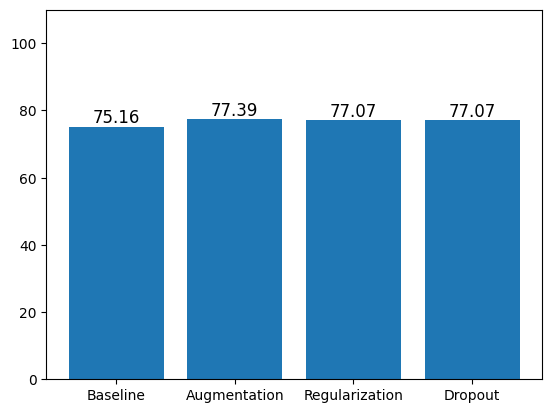

In [46]:
bar = plt.bar(acc_dict.keys(), acc_dict.values())
for rect in bar:
    height = rect.get_height()
    plt.text(rect.get_x() + rect.get_width()/2.0, height, '%.2f' % height, ha='center', va='bottom', size = 12)
plt.ylim(0, 110)
plt.show()   

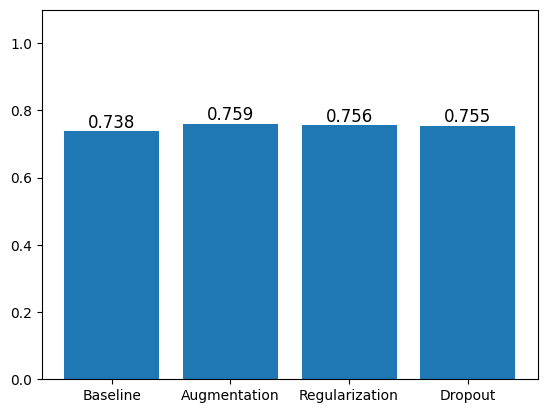

In [47]:
bar = plt.bar(auc_dict.keys(), auc_dict.values())
for rect in bar:
    height = rect.get_height()
    plt.text(rect.get_x() + rect.get_width()/2.0, height, '%.3f' % height, ha='center', va='bottom', size = 12)
plt.ylim(0, 1.1)
plt.show()   


---
## 8. 실습 데이터 불러오기 및 딥러닝 기법 적용
---
### 8.1 실습 데이터 불러오기
모든 전처리가 끝난 실습데이터를 불러오겠습니다.

In [48]:
df = pd.read_csv('./data/processed.csv') # df: dataframe의 줄임말
df.drop(columns = df.columns[0], axis = 1, inplace= True) # 데이터 순서를 표현하는 첫 열을 제거합니다.
display(df)

,Spacegroup,Formation Energy (eV),E Above Hull (eV),Band Gap (eV),Nsites,Density (gm/cc),Has Bandstructure,Crystal System
0,-0.9460,0.96830,1.1120,-1.5800,0.74170,2.61300,-2.0500,0.03653
1,-0.9460,-1.51900,-0.8633,1.1600,-0.55500,-0.63300,-2.0500,0.03653
2,-0.8640,0.07587,-0.4023,0.9644,-0.55500,1.21500,0.4863,1.16200
3,-0.7820,0.15210,0.9810,-1.0090,0.74170,1.06500,0.4863,-1.08900
4,-0.9460,-0.09820,0.8490,-0.2323,0.09344,-1.55700,0.4863,0.03653
...,...,...,...,...,...,...,...,...
324,-0.1285,0.51100,-1.4560,0.5635,-0.29570,0.49440,0.4863,1.16200
325,1.5060,0.51660,-1.4230,0.6226,-0.29570,0.68360,0.4863,1.16200
326,-0.9460,0.50600,1.3430,-1.0150,-0.72800,0.13280,0.4863,0.03653
327,-0.8640,-0.26680,0.6846,0.5664,-0.55500,-0.11304,0.4863,1.16200


---
### 8.2 학습 & 테스트 데이터 구분
7:3 의 비율로 학습 데이터와 테스트 데이터를 구분합니다.

이때 Crystal System 데이터를 정답 데이터로 분리합니다.

In [49]:
target_col = 'Crystal System'

y = df[target_col]
y = y.astype('category').cat.codes
X = df.drop(target_col, axis=1)
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3, random_state=random_seed)

Y_train = to_categorical(Y_train)
Y_test_cat = to_categorical(Y_test)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(230, 7)
(99, 7)
(230, 3)
(99,)


---
### 8.3 MLP 모델 구성
은닉층 5개를 사용하는 MLP 모델을 구성하겠습니다.

아무 기법도 적용하지 않은 베이스라인 모델 먼저 학습하겠습니다.

In [50]:
model = tf.keras.Sequential([
    Input(shape=X_train.shape[1]),
    tf.keras.layers.Dense(1024, activation = 'relu'),
    tf.keras.layers.Dense(512, activation = 'relu'),
    tf.keras.layers.Dense(256, activation = 'relu'),
    tf.keras.layers.Dense(128, activation = 'relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

lr = 0.0001
model.compile(loss = 'categorical_crossentropy',
              optimizer = tf.keras.optimizers.Adam(learning_rate = lr),
              metrics=['accuracy']
)
early_stopping = EarlyStopping(monitor = 'val_loss', min_delta = 0, 
                               patience = 150, mode = 'auto',
                               restore_best_weights=True)

---
### 8.4 모델 학습

In [51]:
epoch = 1000
history = model.fit(X_train, Y_train, 
                        epochs = epoch, 
                        batch_size = 16, 
                        verbose = 0, 
                        validation_data=(X_test, Y_test_cat),
                        callbacks=[early_stopping])

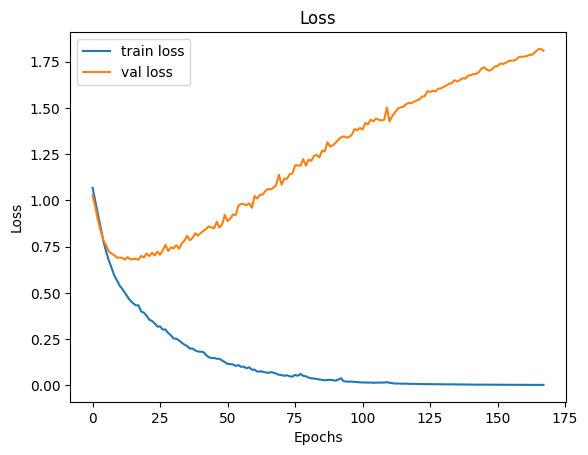

In [52]:
plt.title('Loss')
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend()
plt.show()

In [53]:
def evaluation(prediction, Y_test, model_name="모델 이름"):
    print(model_name, "의 정답률은 %.2f%% 입니다." % (accuracy_score(prediction, Y_test) * 100))
    print(model_name, "의 정밀도는 %.2f 입니다." % precision_score(Y_test, prediction, average='weighted'))
    print(model_name, "의 재현율은 %.2f 입니다." % recall_score(Y_test, prediction, average='weighted'))
    print(model_name, "의 F1 점수는 %.2f 입니다." % f1_score(Y_test, prediction, average='weighted'))
    return accuracy_score(prediction, Y_test) * 100

In [54]:
pred = model.predict(X_test)
pred_classes = np.argmax(pred,axis=1)
acc = evaluation(pred_classes, Y_test, model_name="MLP")

4/4 [==============================] - 0s 2ms/step
MLP 의 정답률은 63.64% 입니다.
MLP 의 정밀도는 0.64 입니다.
MLP 의 재현율은 0.64 입니다.
MLP 의 F1 점수는 0.63 입니다.


In [55]:
acc_dict = {}
acc_dict['Baseline'] = acc

---
### 8.5 딥러닝 기법 적용
데이터 증강, 가중치 규제, 드롭아웃을 적용시키겠습니다.


In [66]:
model_adv = tf.keras.Sequential([
    Input(shape=X_train.shape[1]),
    tf.keras.layers.GaussianNoise(stddev = 0.1),
    tf.keras.layers.Dense(1024, activation = 'relu', kernel_regularizer=tf.keras.regularizers.L2(0.001)),
    tf.keras.layers.Dropout(rate=0.2), 
    tf.keras.layers.Dense(512, activation = 'relu', kernel_regularizer=tf.keras.regularizers.L2(0.001)),
    tf.keras.layers.Dropout(rate=0.2), 
    tf.keras.layers.Dense(256, activation = 'relu', kernel_regularizer=tf.keras.regularizers.L2(0.001)),
    tf.keras.layers.Dropout(rate=0.2), 
    tf.keras.layers.Dense(128, activation = 'relu', kernel_regularizer=tf.keras.regularizers.L2(0.001)),
    tf.keras.layers.Dropout(rate=0.2), 
    tf.keras.layers.Dense(3, activation='softmax')
])

In [67]:

lr = 0.0001
model_adv.compile(loss = 'categorical_crossentropy',
              optimizer = tf.keras.optimizers.Adam(learning_rate = lr),
              metrics=['accuracy']
)
early_stopping = EarlyStopping(monitor = 'val_loss', min_delta = 0, 
                               patience = 150, mode = 'auto',
                               restore_best_weights=True)

In [68]:
epoch = 1000
history = model_adv.fit(X_train, Y_train, 
                        epochs = epoch, 
                        batch_size = 16, 
                        verbose = 0, 
                        validation_data=(X_test, Y_test_cat),
                        callbacks=[early_stopping])

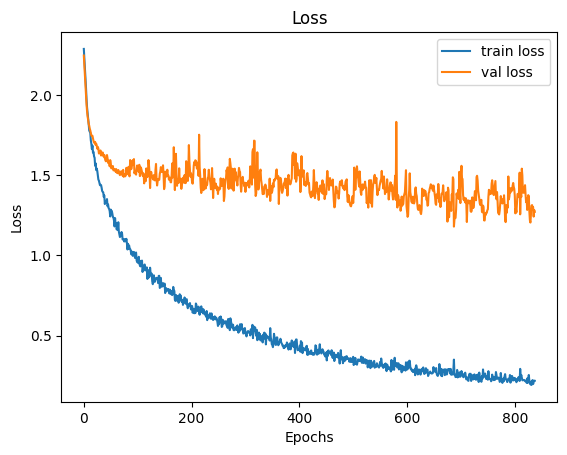

In [69]:
plt.title('Loss')
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend()
plt.show()

In [70]:
pred = model_adv.predict(X_test)
pred_classes = np.argmax(pred,axis=1)
acc = evaluation(pred_classes, Y_test, model_name="개선된 MLP")

4/4 [==============================] - 0s 2ms/step
개선된 MLP 의 정답률은 73.74% 입니다.
개선된 MLP 의 정밀도는 0.74 입니다.
개선된 MLP 의 재현율은 0.74 입니다.
개선된 MLP 의 F1 점수는 0.74 입니다.


In [71]:
acc_dict['Advanced'] = acc

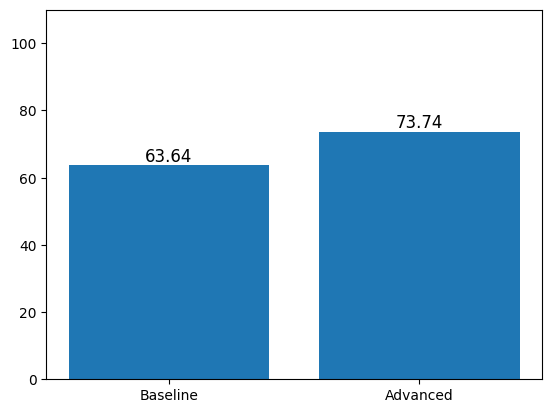

In [72]:
bar = plt.bar(acc_dict.keys(), acc_dict.values())
for rect in bar:
    height = rect.get_height()
    plt.text(rect.get_x() + rect.get_width()/2.0, height, '%.2f' % height, ha='center', va='bottom', size = 12)
plt.ylim(0, 110)
plt.show()   

모델의 성능을 향상시키는 다양한 기법이 있지만, 해당 기법이 언제나 모델의 성능을 향상시켜 주는 것은 아닙니다. 따라서 데이터의 상태나 기법 후 성능 변화를 지켜보며 최적의 모델을 구현해나가는 과정이 중요합니다.

---
## 9. AutoML

인공신경망 모델에는 모델의 구조, 활성화 함수, 학습률 등 튜닝해야 할 파라미터가 매우 많습니다.

파라미터를 어떻게 튜닝하는냐에 따라 성능이 크게 좌우되기도 합니다.

이러한 과정을 줄여줄 수 있는 방법이 AutoML 기술입니다.

AutoML을 실습 데이터에 적용해보겠습니다.

---
### 9.1 AutoML 적용

In [63]:
from autokeras import StructuredDataClassifier

Using TensorFlow backend


In [64]:
auto_model = StructuredDataClassifier(max_trials=30, overwrite=True)

auto_model.fit(X_train, Y_train, validation_data=(X_test, Y_test_cat))

Trial 30 Complete [00h 00m 07s]
val_accuracy: 0.6868686676025391

Best val_accuracy So Far: 0.7373737096786499
Total elapsed time: 00h 04m 56s
INFO:tensorflow:Oracle triggered exit


INFO:tensorflow:Assets written to: ./structured_data_classifier/best_model/assets


INFO:tensorflow:Assets written to: ./structured_data_classifier/best_model/assets


기존 학습된 모델보다 더 좋은 검증 정답률을 보이는 모델을 자동으로 찾았습니다.

In [65]:
model = auto_model.export_model()
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 7)]               0         
                                                                 
 multi_category_encoding (Mu  (None, 7)                0         
 ltiCategoryEncoding)                                            
                                                                 
 normalization (Normalizatio  (None, 7)                15        
 n)                                                              
                                                                 
 dense (Dense)               (None, 32)                256       
                                                                 
 re_lu (ReLU)                (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 16)                528   

모델의 구조는 위와 같습니다.

AutoML의 알고리즘은 구현 방식에 따라 랜덤성에 크게 의존하기 때문에, 시도 횟수를 늘리는 것이 좋습니다.